In [28]:
import pandas as pd
import numpy as np

## Feature Engineering 

### Delivery Time

In [29]:
main_df = pd.read_csv('../data/cleaned_dataset.csv')
main_df.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 141
order_delivered_carrier_date     1961
order_delivered_customer_date    1960
order_estimated_delivery_date       0
order_item_id                     767
product_id                        767
seller_id                         767
shipping_limit_date               767
price                             767
freight_value                     767
product_category_name               0
product_name_length              2370
product_description_length       2370
product_photos_qty               2370
product_weight_g                  785
product_length_cm                 785
product_height_cm                 785
product_width_cm                  785
seller_zip_code_prefix            767
seller_city                       767
seller_state                      767
payment_type_count                  3
used_credit_

In [30]:
main_df['delivery_time_days'] = np.nan

# Correcting DataType
main_df['order_purchase_timestamp'] = pd.to_datetime(
    main_df['order_purchase_timestamp']
)
main_df['order_delivered_customer_date'] = pd.to_datetime(
    main_df['order_delivered_customer_date']
)


mask = (
    (main_df['order_status'] == 'delivered') &
    (main_df['order_delivered_customer_date'].notna())
)

main_df.loc[mask, 'delivery_time_days'] = (
    main_df.loc[mask, 'order_delivered_customer_date'] -
    main_df.loc[mask, 'order_purchase_timestamp']
).dt.days

main_df['delivery_time_days'].head()

0     8.0
1    13.0
2     9.0
3    13.0
4     2.0
Name: delivery_time_days, dtype: float64

### Shipping Duration

In [31]:
main_df['shipping_duration'] = np.nan

# Correcting DataType
main_df['order_delivered_carrier_date'] = pd.to_datetime(
    main_df['order_delivered_carrier_date']
)

mask = (
    (main_df['order_delivered_carrier_date'].notna()) &
    (main_df['order_delivered_customer_date'].notna())
)

main_df.loc[mask, 'shipping_duration'] = (
    main_df.loc[mask, 'order_delivered_customer_date'] -
    main_df.loc[mask, 'order_delivered_carrier_date']
).dt.days

main_df['shipping_duration'].head()

0     6.0
1    12.0
2     9.0
3     9.0
4     1.0
Name: shipping_duration, dtype: float64

### Order Processing Time

In [32]:
main_df.loc[(main_df['order_approved_at'].isnull()) &
            ~(main_df['order_status'] == 'delivered')] # 141 rows

main_df['order_processing_days'] = np.nan

# Correcting DataType
main_df['order_approved_at'] = pd.to_datetime(
    main_df['order_approved_at']
)
main_df['order_purchase_timestamp'] = pd.to_datetime(
    main_df['order_purchase_timestamp']
)

mask = (
    (main_df['order_approved_at'].notna()) &
    (main_df['order_status'] == 'delivered')
)

main_df.loc[mask, 'order_processing_days'] = (
    main_df.loc[mask, 'order_approved_at'] -
    main_df.loc[mask, 'order_purchase_timestamp']
).dt.days

main_df['order_processing_days'].head()


0    0.0
1    1.0
2    0.0
3    0.0
4    0.0
Name: order_processing_days, dtype: float64

### Customer Lifetime Value

In [33]:
main_df['customer_lifetime_value'] = (
    main_df.groupby('customer_unique_id')['total_payment_value']
           .transform('sum')
)
main_df['customer_lifetime_value'].head()

0     82.82
1    141.46
2    179.12
3     72.20
4     28.62
Name: customer_lifetime_value, dtype: float64

### Average Product Price

In [34]:
main_df['Average_product_price'] = (
    main_df.groupby('product_id')['price']
           .transform('mean')
)
main_df['Average_product_price'].head()

0     29.990000
1    119.216038
2    159.233333
3     42.750000
4     21.800000
Name: Average_product_price, dtype: float64

### Customer Purchase Count

In [35]:
main_df['customer_purchase_count'] = main_df.groupby('customer_unique_id')['order_id'].transform('nunique')

main_df['customer_purchase_count'].head()


0    2
1    1
2    1
3    1
4    1
Name: customer_purchase_count, dtype: int64

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

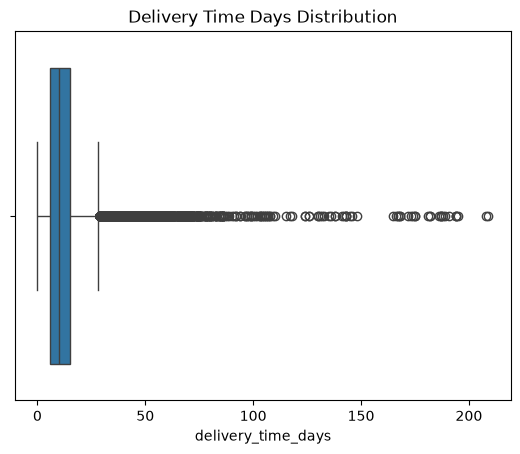

In [37]:
# Detecting Delivery Time Outiler
sns.boxplot(x=main_df["delivery_time_days"])
plt.title("Delivery Time Days Distribution")
plt.show()


In [38]:
Q1 = main_df["delivery_time_days"].quantile(0.25)
Q3 = main_df["delivery_time_days"].quantile(0.75)

# Calculating InterQuartileRange
IQR = Q3 - Q1
# Calculating Lower and Upper Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: -7.5
Upper Bound: 28.5


In [39]:
delivery_time_days_outliers = main_df[ (main_df["delivery_time_days"] < lower_bound) | (main_df["delivery_time_days"] > upper_bound)]
print(delivery_time_days_outliers.shape)

(5557, 43)


In [40]:
delivery_time_days_outliers[["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","delivery_time_days"]].sort_values(by="delivery_time_days", ascending=False)
# Even though it has nearly 200 delivery_time_days but it contains all other data correclty.

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,delivery_time_days
22303,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,209.0
63363,2018-02-23 14:57:35,2018-02-23 15:16:14,2018-02-26 18:49:07,2018-09-19 23:24:07,208.0
70134,2017-03-07 23:59:51,2017-03-09 01:11:33,2017-03-15 13:00:08,2017-09-19 15:12:50,195.0
80132,2017-03-08 18:09:02,2017-03-08 18:09:02,2017-03-13 08:54:02,2017-09-19 14:33:17,194.0
101545,2017-03-08 22:47:40,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,194.0
...,...,...,...,...,...
37042,2018-03-07 15:08:14,2018-03-07 15:32:10,2018-03-08 22:30:43,2018-04-05 19:23:32,29.0
112114,2017-08-09 17:26:44,2017-08-09 17:43:53,2017-08-14 17:18:57,2017-09-08 17:17:51,29.0
112090,2017-10-24 11:34:51,2017-10-24 11:49:37,2017-11-07 21:42:03,2017-11-22 14:53:11,29.0
111887,2018-02-13 17:27:56,2018-02-15 04:11:10,2018-02-16 02:18:33,2018-03-14 22:11:23,29.0


In [41]:
main_df.to_csv('../data/featured_dataset.csv', index=False)